<a href="https://colab.research.google.com/github/Auliaashylla01/CheckPoint-AVD/blob/main/Checkpoint4/CheckPoint_4_AVD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Check Point 4**

Oleh Aulia Ashylla Ananda Putri Hariawan (2509116076)

#**Loan Approval**

Sebuah lembaga keunagan ingin meninjau proses persetujuan pinjaman agar keputusan yang dilakukan lebih adil dan berdasarkan data yang jelas. Proses persetujuan pinjaman dilakukan dengan mempertimbangkan beberapa hal seperti usia pemohon, besar pendapatan, status pekerjaan dan jumlah pinjaman yang diajukan. Oleh karena itu lembaga keuangan ingin mengetahui faktor mana yang paling berpengaruh terhadap persetujuan pinjaman.  

#Import Library

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import  matplotlib.pyplot as plt

#**Business Understanding**

##Business Objective

Dataset Loan Approval

Dataset ini berisi data pengajuan pinjaman yang mencakup beberapa variabel seperti umur pemohon, jenis kelamin, status pernikahan, pendapatan, status pekerjaan, jumlah pinjaman yang diajukan, serta status persetujuan pinjaman. Tujuan pembahasan ini adalah untuk meninjau ulang proses persetujuan pinjaman agar keputusan yang diambil lebih adil dan memiliki dasar yang jelas, Karena proses keputusan persetujuan pinjaman mengacu pada beberapa pertimbangan umum dan tanpa analisis yang terstruktur.

Melalui dataset ini diharapkan dapat memahami faktor utama yang memengaruhi persetujuan pinjaman. Selain itu untuk meningkatkan konsistensi pengambilan keptusan dalam proses persetujuan pinjaman sehingga tidak terjadi perbedaan penilaian antar pemohon dengan kondisi yang serupa.

Dataset ini terdapat 1000 baris dan 11 kolom.



##Assess Situation

Dataset ini berisi informasi finansial dan demografis dari 1.000 pemohon pinjaman, termasuk pendapatan tahunan, skor kredit, jumlah pinjaman, jumlah tanggungan, status pekerjaan, dan status persetujuan. Variabel target memiliki dua nilai: 1 (disetujui) atau 0 (ditolak). Tantangan dalam dataset ini kemungkinan adanya ketidakseimbangan jumlah antara pinjaman yang disetujui dan ditolak, yang dapat memengaruhi penilaian hasil analisis.

Selain itu perlu adanya perhatian lebih adanya data kosong, inkonsistensi format, atau nilai yang sangat tinggi atau rendah pada variabel seperti pendapatan dan jumlah pinjaman. Tantangan lainnya adalah memastikan variabel-variabel dalam dataset sesuai dengan tujuan analisis, sehingga informasi yang diperoleh dapat digunakan secara tepat.

##Analytic Goals & Project Plans

Dalam dataset ini akan dilakukan:

*   Mengidentifikasi tren dan pola persetujuan Pinjaman: Melihat apakah usia, pendapatan, atau status pekerjaan berhubungan dengan kemungkinan pinjaman disetujui.
*   Menganalisis faktor penentu Persetujuan: variabel-variabel seperti pendapatan, jumlah pinjaman, dan status pekerjaan untuk mengetahui faktor mana yang paling memengaruhi keputusan persetujuan.
*   Menilai keseimbangan data: Perbedaan jumlah pemohon yang disetujui dan ditolak, sehingga menghindari potensi bias dari ketidakseimbangan data.
*   Membuat visualisasi data: Menyajikan pola dan tren dalam bentuk grafik ataupun diagram agar hubungan antar variabel lebih mudah dipahami.
*   Memberikan informasi untuk pengambilan: Menyediakan standar persetujuan pinjaman yang lebih adil, konsisten, dan berbasis data.
*   Menyiapkan Dasar Analisis Lanjutan: Sebagai referensi pengembangan model prediksi persetujuan pinjaman.







#**Data Understanding**

##**Memuat Dataset**

In [ ]:
file = "/content/drive/MyDrive/loan_data/loanapproval.csv"
df = pd.read_csv(file)
df

,applicant_id,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved,income_loan_ratio,income_loan_category
0,1,59,Male,Divorced,100073,7169,793,1,1,Unemployed,1,0.071638,Beban Ringan
1,2,49,Male,Married,112197,23556,789,0,2,Employed,1,0.209952,Beban Sedang
2,3,35,Male,Divorced,84429,27052,372,1,4,Unemployed,0,0.320411,Beban Sedang
3,4,63,Female,Single,124195,11313,808,3,4,Self-employed,1,0.091091,Beban Ringan
4,5,28,Female,Married,81627,13315,689,0,1,Unemployed,1,0.163120,Beban Ringan
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,53,Female,Married,135598,6014,767,3,2,Employed,1,0.044352,Beban Ringan
996,997,22,Male,Single,139028,15103,662,0,0,Self-employed,1,0.108633,Beban Ringan
997,998,34,Female,Married,147517,21986,582,0,2,Employed,1,0.149040,Beban Ringan
998,999,60,Female,Divorced,73161,49781,635,4,0,Unemployed,1,0.680431,Beban Tinggi


##**Deskripsi Data**

###**Informasi Lanjutan**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   applicant_id          1000 non-null   int64 
 1   age                   1000 non-null   int64 
 2   gender                1000 non-null   object
 3   marital_status        1000 non-null   object
 4   annual_income         1000 non-null   int64 
 5   loan_amount           1000 non-null   int64 
 6   credit_score          1000 non-null   int64 
 7   num_dependents        1000 non-null   int64 
 8   existing_loans_count  1000 non-null   int64 
 9   employment_status     1000 non-null   object
 10  loan_approved         1000 non-null   int64 
dtypes: int64(8), object(3)
memory usage: 86.1+ KB


1. applicant_id:
Jumlah baris: 1000   
Tipe data: int64
Deskripsi: ID unik untuk setiap pemohon pinjaman.


2. age:
Jumlah baris: 1000
Tipe data: int64
Deskripsi: Usia pemohon pinjaman dalam tahun.

3. gender:
Jumlah baris: 1000
Tipe data: object
Deskripsi: Jenis kelamin pemohon.

4. marital_status:
Jumlah baris: 1000
Tipe data: object
Deskripsi: Status pernikahan pemohon (misalnya: single, married).

5. annual_income:
Jumlah baris: 1000
Tipe data: int64
Deskripsi: Pendapatan tahunan pemohon.

6. loan_amount:
Jumlah baris: 1000
Tipe data: int64
Deskripsi: Jumlah pinjaman yang diajukan.

7. credit_score:
Jumlah baris: 1000
Tipe data: int64
Deskripsi: Skor kredit pemohon yang menunjukkan kelayakan kredit.

8. num_dependents:
Jumlah baris: 1000
Tipe data: int64
Deskripsi: Jumlah tanggungan yang dimiliki pemohon.

9. existing_loans_count:
Jumlah baris: 1000
Tipe data: int64
Deskripsi: Jumlah pinjaman lain yang sedang dimiliki pemohon.

10. employment_status:
Jumlah baris: 1000
Tipe data: object
Deskripsi: Status pekerjaan pemohon (misalnya: employed, self-employed, unemployed).

11. loan_approved
Jumlah baris: 1000
Tipe data: int64
Deskripsi: Status persetujuan pinjaman (biasanya 1 = disetujui, 0 = ditolak).

###**Informasi Statistik Deskriptif**

In [ ]:
df.describe(include='all')

,applicant_id,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved
count,1000.000000,1000.000000,1000,1000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000,1000.000000
unique,NaN,NaN,2,3,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,Male,Married,NaN,NaN,NaN,NaN,NaN,Self-employed,NaN
freq,NaN,NaN,524,355,NaN,NaN,NaN,NaN,NaN,350,NaN
mean,500.500000,42.515000,NaN,NaN,81972.972000,27244.866000,576.125000,1.97700,2.042000,NaN,0.729000
std,288.819436,12.611059,NaN,NaN,37547.255418,12822.752877,155.921483,1.41862,1.413589,NaN,0.444699
min,1.000000,21.000000,NaN,NaN,20155.000000,5082.000000,300.000000,0.00000,0.000000,NaN,0.000000
25%,250.750000,32.000000,NaN,NaN,48913.250000,16587.500000,443.750000,1.00000,1.000000,NaN,0.000000
50%,500.500000,43.000000,NaN,NaN,82050.000000,27041.500000,573.500000,2.00000,2.000000,NaN,1.000000
75%,750.250000,53.000000,NaN,NaN,113556.000000,37939.250000,713.250000,3.00000,3.000000,NaN,1.000000


1. Count (Kelengkapan Data)   

Berdasarkan data, total baris data pinjaman adalah 1000. Seluruh kolom memiliki jumlah data 1000 non-null, sehingga tidak terdapat selisih antara total baris dan jumlah data pada masing-masing kolom. Maka dapat disimpulkan bahwa Semua kolom pada dataset ini lengkap dan tidak mengandung missing values.


---


2. Mean vs Median (Distribusi Data)   
*   Kolom Age
    *   Mean = 42,51
    *   Median = 43,00

Nilai mean dan median hampir sama, sehingga dapat disimpulkan bahwa distribusi usia relatif simetris dan tidak terdapat perbedaan ekstrem yang signifikan. Rentang usia berada antara 21 hingga 64 tahun.  

*   Kolom Annual Income
    *   Mean = 81.972,97
    *   Median = 82.050,00

Nilai rata-rata dan median sangat berdekatan, menunjukkan bahwa distribusi pendapatan tahunan cukup seimbang dan tidak terlalu dipengaruhi oleh outlier ekstrem. Pendapatan minimum sebesar 20.155 dan maksimum 149.951.

*   Kolom Loan Amount
    *   Mean = 27.244,87
    *   Median = 27.041,50

Mean sedikit lebih tinggi dari median, namun selisihnya kecil. Ini menunjukkan distribusi jumlah pinjaman relatif normal.

*   Kolom Credit Score
    *   Mean = 576,13
    *   Median = 573,50

Nilai rata-rata dan median hampir sama, menandakan distribusi skor kredit cukup merata tanpa perbedaan ekstrem yang signifikan.

*   Kolom Num Dependents
    *   Mean = 1,98
    *   Median = 2,00

Distribusi jumlah tanggungan sangat seimbang karena mean dan median hampir identik.

*   Kolom Existing Loans Count
    *   Mean = 2,04
    *   Median = 2,00

Perbedaan sangat kecil antara mean dan median menunjukkan distribusi yang stabil dan tidak terlalu condong.

*   Kolom Loan Approved
    *   Mean = 0,729

Karena variabel ini berbentuk biner (0 = ditolak, 1 = disetujui), nilai mean 0,729 menunjukkan bahwa sekitar 72,9% pengajuan pinjaman disetujui, sementara sisanya sekitar 27,1% ditolak.

Kesimpulan: Secara keseluruhan, data cenderung **simetris dan stabil**, karena nilai mean dan median pada sebagian besar variabel hampir sama serta tidak dipengaruhi outlier ekstrem.


---

3. Min dan Max (Validasi Logika)

*   Age
    *   Min = 21
    *   Max = 64

*   Annual Income
    *   Min = 20.155
    *   Max = 149.951

*   Loan Amount
    *   Min = 5.082
    *   Max = 49.864

*   Credit Score
    *   Min = 300
    *   Max = 849

*   Num Dependents
    *   Min = 0
    *   Max = 4

*   Existing Loans Count
    *   Min = 0
    *   Max = 4

*   Loan Approved
    *   Min = 0
    *   Max = 1

Kesimpulan:

1.   Rentang usia 21–64 tahun masih dalam kategori usia produktif sehingga masih aman untuk pengajuan pinjaman.
2. Pendapatan tahunan dan jumlah pinjaman memiliki rentang yang cukup besar tapi masih masuk akal dalam konteks finansial.
3. Skor kredit 300–849 juga berada dalam batas wajar sistem penilaian kredit.
4. Jumlah tanggungan dan pinjaman aktif (0–4) tergolong masuk akal.

Secara keseluruhan, tidak ditemukan nilai ekstrem yang tidak logis atau indikasi kesalahan input yang signifikan.


---

4. Standar Deviasi (std) - Variabilitas Data

*   Age
    *   Mean = 42,51
    *   Std = 12,61   

Artinya umur pemohon cukup beragam, tapi masih di rentang usia produktif dan nggak terlalu ekstrem.

*   Annual Income
    *   Mean = 81.972,97
    *   Std = 37.547,26  

Standar deviasinya lumayan besar, berarti perbedaan pendapatan antar pemohon cukup jauh (ada yang rendah, ada yang tinggi).

*   Loan Amount
    *   Mean = 27.244,87
    *   Std = 12.822,75

Jumlah pinjaman juga cukup bervariasi, menyesuaikan dengan kondisi dan kebutuhan masing-masing pemohon.

*   Credit Score
    *   Mean = 576,13
    *   Std = 155,92

Skor kredit penyebarannya cukup lebar, jadi tingkat risiko pemohon beda-beda, dari yang kurang bagus sampai yang bagus.

*   Num Dependents
    *   Mean = 1,98
    *   Std = 1,42

Jumlah tanggungan masih tergolong wajar dan variasinya nggak terlalu ekstrem.

*   Existing Loans Count
    *   Mean = 2,04
    *   Std = 1,41

Pinjaman aktif tiap orang beda-beda, tapi masih dalam batas normal.

*  Loan Approved
    *   Mean = 0,729
    *   Std = Std = 0,445  
    
Karena ini data 0 dan 1, artinya memang ada variasi antara yang disetujui dan ditolak, tapi mayoritas tetap disetujui.

Kesimpulan:
Secara umum, variasi paling kelihatan ada di pendapatan, jumlah pinjaman, dan skor kredit. Tapi semuanya masih masuk akal dan nggak ada yang terlalu ekstrem.

















##**Verifikasi Kualitas Data**

###**Data Type Check**

In [ ]:
df.dtypes

,0
applicant_id,int64
age,int64
gender,object
marital_status,object
annual_income,int64
loan_amount,int64
credit_score,int64
num_dependents,int64
existing_loans_count,int64
employment_status,object


Semua tipe data perkolom sudah benar semua dan tidak ada yang perlu di ganti. Data yang terdiri dari angka menggunakan tipe data integer dan untuk data yang ditulis dalam format huruf dan bisa juga merupakan campuran huruf dan angka menggunakan tipe data object.

###**Inconsistent Values**

1. **applicant_id**

Pada kolom applicant_id, format penulisan sudah **konsisten** dan unik untuk setiap baris. Semua nilai berupa bilangan integer tanpa desimal, dari 1 hingga 1000, sehingga tidak ada duplikasi atau kesalahan format.

In [ ]:
print(df['applicant_id'].unique())

[   1    2    3    4    5    6    7    8    9   10   11   12   13   14
   15   16   17   18   19   20   21   22   23   24   25   26   27   28
   29   30   31   32   33   34   35   36   37   38   39   40   41   42
   43   44   45   46   47   48   49   50   51   52   53   54   55   56
   57   58   59   60   61   62   63   64   65   66   67   68   69   70
   71   72   73   74   75   76   77   78   79   80   81   82   83   84
   85   86   87   88   89   90   91   92   93   94   95   96   97   98
   99  100  101  102  103  104  105  106  107  108  109  110  111  112
  113  114  115  116  117  118  119  120  121  122  123  124  125  126
  127  128  129  130  131  132  133  134  135  136  137  138  139  140
  141  142  143  144  145  146  147  148  149  150  151  152  153  154
  155  156  157  158  159  160  161  162  163  164  165  166  167  168
  169  170  171  172  173  174  175  176  177  178  179  180  181  182
  183  184  185  186  187  188  189  190  191  192  193  194  195  196
  197 

2. **age**

Pada kolom age, nilai-nilai data nya **konsisten** dan berupa bilangan integer tanpa desimal. Rentangnya dari 21 hingga 64 tahun, menunjukkan semua pemohon berada di usia produktif. Tidak ada nilai yang ekstrem atau yang tidak logis.



In [ ]:
print(df['age'].unique())

[59 49 35 63 28 41 39 43 31 44 56 60 23 42 22 64 50 58 53 32 45 47 62 48
 36 57 27 29 38 24 34 46 40 55 37 26 54 30 51 61 21 25 33 52]


3. **gender**

Pada kolom gender format penulisan data nya sama dan konsisten. Gender atau jenis kelamin yang hanya terbagi dua jenis dan dengan format penulisan yang sama semua.

In [ ]:
print(df['gender'].unique())

['Male' 'Female']


4. **marital_status**

Pada kolom marital status atau status pernikahan format penulisan data nya konsisten. Dengan 3 kategori status pernikahan dengan format penulisan yang sama.

In [ ]:
print(df['marital_status'].unique())

['Divorced' 'Married' 'Single']


5. **annual_income**

Pada kolom annual income atau pendapat tahunan menggunakan tipe data integer tanpa ada desimal, tanpa ada satuan mata uang dan nol berlebih di belakang nya. Jadi dapat dikatakan **konsisten**

In [ ]:
print(df['annual_income'].unique())

[100073 112197  84429 124195  81627  53848  57804  35379  79664  47766
 129126  88099  56060 114733  89122  36087  68868 139119  43225 115286
  26643 113059  56727  31005 129079  85697  36029 135281  34226  83646
  80603  48731 129458 130384  88926  25997  75506  98229  69815  62092
  82539  86077  41817  57861  33428  63934 135555 134367  30258  77775
 101580 114947  25469  48854  26256 144086  96256  53937 119134  21651
  70288 104730  45051  47386  95054 131562  36184  53787  41621  95564
  97984  79792  65253  54051  69811  50447 148046 103930 143278 120037
  50254 104045 136859  77418 134534  34472 131193  23471 127332 140312
 143379 115804  28329  54865  66850  74220 132234 113808 128381  26397
 117909 149004  55525  73072 110106 103820 104530  43284  81330 103369
  45122  90553 101906 114788  82812  27999  42436  62963  22096 149940
 133737  45279 141092 128899 134245  46201  39715  49309  35078  76614
  25105 137666 114848  22839  88920  63619  62821 145736  33493  37069
 13244

6. **loan_amount**

Pada kolom loan amount atau besar pokok pinjaman, penulisan format data sama atau dapat dikatakan **konsisten**. Format penulisan data tanpa desimal dan tanpa ada mata uang pada tabel.

In [ ]:
print(df['loan_amount'].unique())

[ 7169 23556 27052 11313 13315 13036 36778 32734 28173 35403  5785 11139
 11344 23800 30372 25538 19973 10619 39704 41575 44919 47261 32716  8236
 20848  7352  6932 15913 13556 26300 10498 15582 14569  9857  5340 48949
 21766 31132 13491  5138  5358 14714 24840 39395 35654 30879 20996 42772
 31762 18283 44420 24554 25219 39919 14429 49695 44673 24218 17452 23951
  6307 19852 30232 40428 48171 31485 15238 43975  6140 29842 31421  6708
  8630 24595 15485 33308 49789 31086 21859 12684 30552  6207  6960  5557
 34689 18893 37272  5882 42529 43635 34535 17869 12166 17982 45697 43115
 12269 33064 18527  7454 25878 17991  7808 44410 41593 41304 35386  8802
 33753 26083 23354 27190 11142 33398 46862 38132 24503 39631 21499 44852
 13016  7384 20072 41703 19482 45510 26826  7490 30518 29045 31910 29566
 38905 32103 41188 10845 26162 41674 24337 27313 31943 17413  5276 22611
 44105 16944 20906 25536 32810 17306 15503 24225 41976 16590 15886 17866
  6088  8363 37792 14764 25620 47727 17935 13068 12

7. **credit_score**

Pada kolom credit score atau skor kredit pinjaman penulisan data nya **konsisten** dan tidak ada format yang berbeda pada setiap data.

In [ ]:
print(df['credit_score'].unique())

[793 789 372 808 689 594 668 848 486 744 662 422 487 719 551 634 391 829
 362 811 438 484 504 513 555 434 387 506 428 302 420 684 337 640 320 541
 754 602 368 495 439 743 582 611 834 576 360 618 351 452 610 843 688 847
 476 661 613 396 512 436 305 408 846 338 724 560 725 386 764 375 770 713
 756 584 538 671 794 344 700 546 749 784 317 588 534 715 798 414 533 839
 310 505 426 446 417 681 711 474 780 318 494 629 748 653 440 392 732 544
 616 581 316 370 568 624 604 750 306 402 492 828 470 836 550 686 840 679
 443 324 804 635 663 498 712 638 728 841 356 531 734 683 493 833 817 591
 415 348 381 632 831 520 622 339 358 806 421 778 395 361 647 423 781 803
 347 708 435 500 549 667 779 799 654 510 343 564 519 741 699 769 566 353
 827 819 536 685 599 694 813 477 695 670 617 521 455 677 736 687 639 503
 460 691 369 704 816 419 516 355 665 403 376 529 557 563 630 481 849 326
 575 598 390 757 664 650 552 758 807 603 800 465 714 761 413 655 814 507
 424 437 367 682 373 490 614 412 469 767 313 587 48

8. **num_dependents**

Pada kolom num dependents atau jumlah tanggungan oleh peminjam, punya besar data 0-5 dan format penulisan nya sama semua atau **konsisten** karena semua di tulis dengan bilangan bulat.

In [ ]:
print(df['num_dependents'].unique())

[1 0 3 2 4]


9. **existing_loans_count**

Pada kolom existing loans count atau jumlah pinjaman aktif, punya jangkauan 0-5 dan dengan format penulisan yang **konsisten**.

In [ ]:
print(df['existing_loans_count'].unique())

[1 2 4 0 3]


10. **employment_status**

Pada kolom employment status, peminjam terbagi menjadi 3 kategori dan format penulisan kategori status bekerja **konsisten** dengan huruf kapital di awal kata.

In [ ]:
print(df['employment_status'].unique())

['Unemployed' 'Employed' 'Self-employed']


11. **loan_approved**

Pada kolom loan approved atau pinjaman disetujui format penulisan data nya konsisten dengan tipe data integer. Dengan angka 1 sebagai penanda pinjaman disetuji dan sebaliknya untuk angka 0.

In [ ]:
print(df['loan_approved'].unique())

[1 0]


###**Missing Values**

Tidak ada missing values pada seluruh kolom di dataset ini. Semua kolom lengkap tanpa data yang hilang, hal ini dapat dilihat dari setiap variabel memiliki rasio 0.0%.

In [ ]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
applicant_id,0.0
age,0.0
gender,0.0
marital_status,0.0
annual_income,0.0
loan_amount,0.0
credit_score,0.0
num_dependents,0.0
existing_loans_count,0.0
employment_status,0.0


###**Duplicated Values**

Di dataset ini tidak ditemukan data duplikat sama sekali, data sudah bersih dan menghindari kesalahan karena adanya duplikasi data.


In [ ]:
df[df.duplicated()]

,applicant_id,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved


###**Outliers Values**

Pada dataset ini tidak terdapat nilai ekstrem (outliers) pada kolom yang bertipe data numerik. Nilai minimum dan maksimum pada setiap kolom masih berada dalam rentang wajar dan sesuai konteks data. Artinya, tidak ada angka yang terlalu jauh atau tidak masuk akal dibandingkan data lainnya.



In [ ]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
applicant_id,0.0
age,0.0
annual_income,0.0
loan_amount,0.0
credit_score,0.0
num_dependents,0.0
existing_loans_count,0.0
loan_approved,0.0


#**Eksplorasi Data (EDA)**

##**Comparison/Perbandingan**

Aktivitas: Membandingkan rata-rata annual income berdasarkan status persetujuan pinjaman (loan_approved).

Tujuan: Mengidentifikasi apakah terdapat perbedaan pendapatan antara pemohon yang disetujui dan ditolak, serta melihat apakah pendapatan berpengaruh terhadap keputusan persetujuan pinjaman.

Visualisasi: Bar Chart (Grafik Batang).

Kesimpulan: Pemohon yang pinjamannya disetujui (loan approved) memiliki rata-rata annual income sekitar 80000, sedangkan yang ditolak memiliki rata-rata sekitar 70000. Selain itu, jumlah pemohon yang disetujui juga lebih banyak dibandingkan yang ditolak. Hal ini menunjukkan bahwa pendapatan tahunan kemungkinan menjadi salah satu faktor yang berpengaruh dalam persetujuan pinjaman.

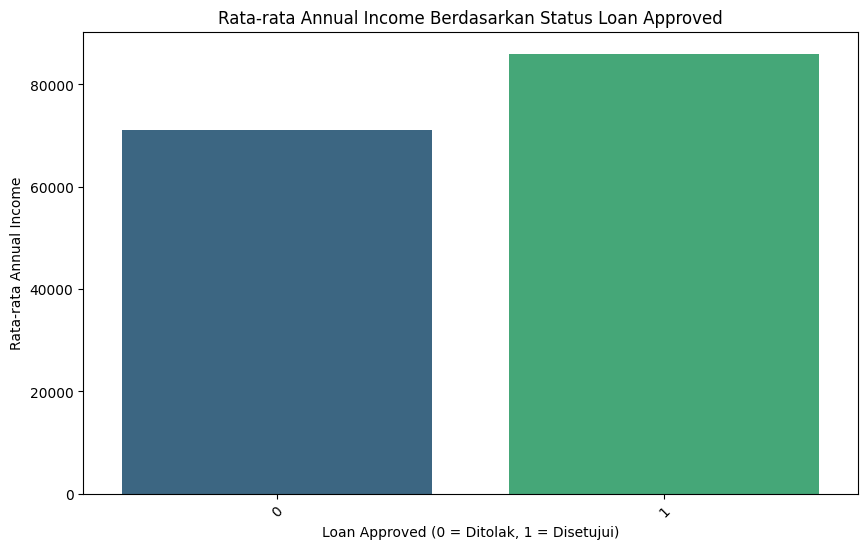

In [ ]:
pinjaman_diterima = df.groupby('loan_approved')['annual_income'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=pinjaman_diterima.index, y=pinjaman_diterima.values, palette='viridis', hue=pinjaman_diterima.index, legend=False)
plt.title('Rata-rata Annual Income Berdasarkan Status Loan Approved')
plt.xlabel('Loan Approved (0 = Ditolak, 1 = Disetujui)')
plt.ylabel('Rata-rata Annual Income')
plt.xticks(rotation=45)
plt.show()

##**Composition/Komposisi**

Aktivitas:Menganalisis proporsi pemohon berdasarkan status pekerjaan (employment_status).

Tujuan: Mengetahui komposisi jenis pekerjaan dalam dataset dan melihat apakah kelompok pekerjaan tertentu mendominasi pengajuan pinjaman.

Visualisasi: Pie Chart (Diagram Lingkaran).

Kesimpulan: Hasil analisis komposisi menunjukkan bahwa pemohon pinjaman terbanyak berasal dari kategori Self-employed dengan proporsi 35%. Meskipun Self-employed merupakan kategori dengan jumlah pengajuan tertinggi perbedaan setiap kategori tidak terlalu jauh dengan kategori lain, sehingga tidak ada satu kategori pekerjaan yang mendominasi pengajuan pinjaman.



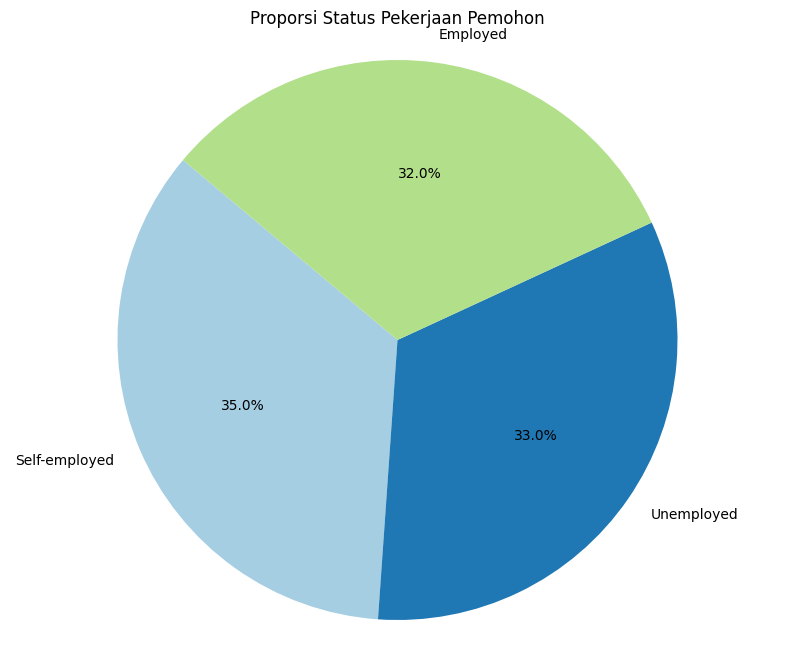

In [ ]:
employment_approved = df.groupby('employment_status')['employment_status'].count().sort_values(ascending=False)
employment_approved= employment_approved.head(3)

plt.figure(figsize=(10, 8))
employment_approved.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Proporsi Status Pekerjaan Pemohon')
plt.ylabel('')
plt.axis('equal')
plt.show()

##**Distribution/Distribusi**

Aktivitas: Menganalisis penyebaran nilai pinjaman pada kolom loan_amount.

Tujuan: Mengetahui apakah mayoritas pemohon mengajukan pinjaman kecil atau besar, serta mendeteksi adanya kecondongan (skewness) dalam data pinjaman.

Visualisasi: Histogram.

Kesimpulan: Distribusi Loan Amount cenderung mendekati normal dan relatif simetris tanpa indikasi outlier yang signifikan. Sebagian besar nilai pinjaman berada pada rentang menengah. Artinya, kebanyakan pemohon mengajukan pinjaman dengan jumlah yang wajar dan tidak terlalu jauh berbeda satu sama lain.

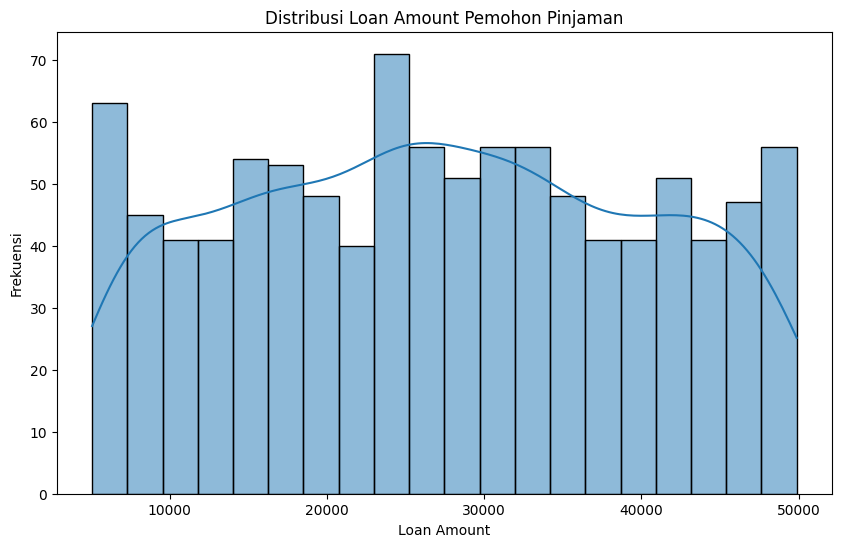

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['loan_amount'], bins=20, kde=True)
plt.title('Distribusi Loan Amount Pemohon Pinjaman')
plt.xlabel('Loan Amount')
plt.ylabel('Frekuensi')
plt.show()

##**Relationship/Hubungan**

Aktivitas: Menganalisis korelasi antara usia pemohon (age) dengan status persetujuan pinjaman (loan_approved).

Tujuan: Mengetahui apakah usia pemohon berpengaruh terhadap keputusan persetujuan pinjaman dan melihat pola usia pemohon yang cenderung disetujui atau ditolak.

Visualisasi: Heatmap Korelasi.

Kesimpulan: Korelasi antara Age dan Loan Approved menunjukkan nilai yang sangat kecil (sekitar 0,02), yang berarti hampir tidak terdapat hubungan linear yang signifikan antara usia pemohon dan persetujuan pinjaman. Artinya, peluang pinjaman disetujui tidak banyak dipengaruhi oleh faktor usia saja. Baik pemohon yang lebih muda maupun yang lebih tua memiliki kemungkinan persetujuan yang relatif sama.

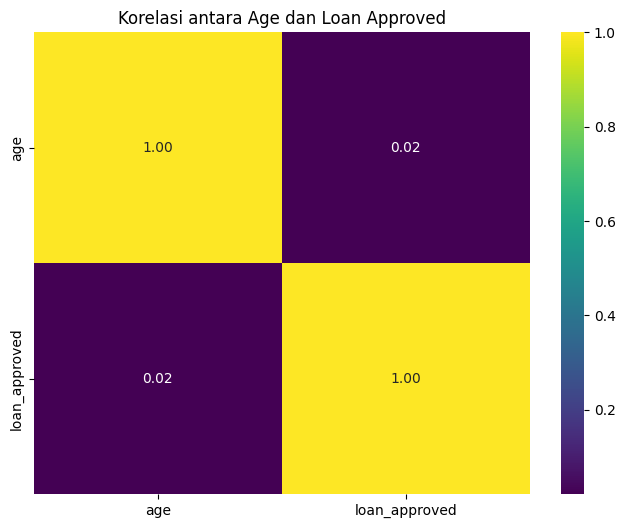

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['age', 'loan_approved']].corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title('Korelasi antara Age dan Loan Approved')
plt.show()

#**Data Preparation**

##**Data Type**

Seluruh kolom pada dataset **sudah menggunakan tipe data yang sesuai** dengan masing-masing variabel. Kolom yang berisi angka dan bersifat bilangan bulat seperti usia, pendapatan, jumlah pinjaman, skor kredit, jumlah tanggungan, jumlah pinjaman aktif, serta status persetujuan pinjaman sudah menggunakan tipe data integer (int64). Sementara itu, kolom yang berisi data kategori dalam bentuk teks seperti gender, marital_status, dan employment_status sudah menggunakan tipe data object. Oleh karena itu, **tidak diperlukan perubahan atau konversi tipe data** karena semua variabel tiap kolom sudah sesuai.


In [ ]:
df.dtypes

,0
applicant_id,int64
age,int64
gender,object
marital_status,object
annual_income,int64
loan_amount,int64
credit_score,int64
num_dependents,int64
existing_loans_count,int64
employment_status,object


##**Inconsistent Values**

Pada seluruh kolom tidak ditemukan nilai yang tidak konsisten pada dataset. Setiap kolom memiliki **format penulisan yang seragam** dan tidak terdapat perbedaan gaya penulisan seperti huruf kecil dan besar yang bercampur, tambahan simbol, maupun variasi kategori yang seharusnya sama.

Kolom yang terdiri dari angka seperti pada kolom age, annual_income, loan_amount, credit_score, num_dependents, existing_loans_count, dan loan_approved seluruhnya ditulis dalam bentuk bilangan bulat tanpa desimal atau simbol tambahan. Rentang nilainya juga masih dalam batas yang logis dan wajar.

Sementara itu, kolom kategori seperti gender, marital_status, dan employment_status memiliki jumlah kategori yang jelas dan konsisten dalam penulisan.

Pada tahap inconsistent values ini **tidak diperlukan perbaikan data** karena seluruh kolom sudah memiliki format yang konsisten

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   applicant_id          1000 non-null   int64 
 1   age                   1000 non-null   int64 
 2   gender                1000 non-null   object
 3   marital_status        1000 non-null   object
 4   annual_income         1000 non-null   int64 
 5   loan_amount           1000 non-null   int64 
 6   credit_score          1000 non-null   int64 
 7   num_dependents        1000 non-null   int64 
 8   existing_loans_count  1000 non-null   int64 
 9   employment_status     1000 non-null   object
 10  loan_approved         1000 non-null   int64 
dtypes: int64(8), object(3)
memory usage: 86.1+ KB


##**Missing Values**

Seluruh kolom pada dataset **tidak ditemukan missing values** atau data yang hilang. Setiap kolom memiliki rasio 0.0%, yang berarti tidak ada satu pun baris yang kosong atau tidak terisi pada kolom mana pun.  Dapat disimpulkan bahwa dataset tidak memerlukan proses seperti penghapusan baris, imputasi nilai rata-rata, maupun median.

In [ ]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
applicant_id,0.0
age,0.0
gender,0.0
marital_status,0.0
annual_income,0.0
loan_amount,0.0
credit_score,0.0
num_dependents,0.0
existing_loans_count,0.0
employment_status,0.0


##**Duplicated Values**

**Tidak ditemukan data yang terduplikasi**. Artinya, setiap baris dalam dataset tidak terjadi adanya pengulangan data yang sama persis pada seluruh kolom  dapat dilihat dalam baris di bawah diamana jika yang muncul hanya baris kolom saja tanpa ada isi datanya maka dapat di pastikan data yang terduplikasikan tidak ada.Maka dapat disimpulkan **tidak diperlukan proses penghapusan data duplikat** karena memang tidak ada baris yang terduplikasi.

In [ ]:
df[df.duplicated()]

,applicant_id,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved


##**Outliers Values**

Seluruh kolom numerik pada dataset ini, **tidak ditemukan adanya nilai ekstrem atau outliers**. Dapat dilihat dari perhitungan persentase outliers yang menunjukkan nilai 0.0% pada setiap kolom numerik. Artinya, tidak ada data yang berada jauh di luar rentang distribusi normal atau menyimpang secara signifikan dari mayoritas nilai lainnya.

Nilai minimum dan maksimum pada setiap kolom masih berada dalam batas yang wajar dan sesuai dengan konteks data. Misalnya, pada kolom usia pemohon masih dalam rentang usia produktif, koom skor kredit berada dalam batas dasar sistem penilaian kredit, dan jumlah tanggungan maupun pinjaman aktif tidak menunjukkan angka yang terlalu rendah atau tinggi.

Dengan demikian, pada tahap ini **tidak diperlukan proses penanganan khusus seperti di imputasi ataupun penghapusan baris**.

In [ ]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
applicant_id,0.0
age,0.0
annual_income,0.0
loan_amount,0.0
credit_score,0.0
num_dependents,0.0
existing_loans_count,0.0
loan_approved,0.0


##**Construct Data**

Pada dataset ini saya ingin menambahkan kolom baru bernama **income_loan_ratio** yang menghubungkan annual_income dan loan_amount dalam bentuk rasio. Tujuan nya untuk menilai apakah**jumlah pinjaman yang diajukan masih tergolong wajar dibanding dengan pendapatan finansial pemohon** pinjaman. Karena pendapatan yang tinggi belum tentu aman apabila jumlah pinjamannya juga sangat besar. Sebaliknya, pinjaman yang terlihat kecil tetap bisa berisiko apabila pendapatan pemohon ternyata rendah.

Manfaat terhadap kualitas data adalah dataset menjadi lebih informatif dan kontekstual. Kolom ini membantu dalam proses evaluasi risiko kredit, mempermudah segmentasi pemohon berdasarkan tingkat beban pinjaman, serta dapat meningkatkan akurasi jika nantinya digunakan dalam model prediksi persetujuan pinjaman.

In [ ]:
df['income_loan_ratio'] = df['loan_amount'] / df['annual_income']

def income_ratio_category(income_loan_ratio):
    if income_loan_ratio <= 0.2:
        return 'Beban Ringan'
    elif income_loan_ratio <= 0.4:
        return 'Beban Sedang'
    else:
        return 'Beban Tinggi'

df['income_loan_category'] = df['income_loan_ratio'].apply(income_ratio_category)

Cek kembali apakah kolom yang baru di buat yaitu kolom **income_loan_category sudah masuk dalam dataset** dan apakah sudah sesuai konteks.

In [ ]:
df.head()

,applicant_id,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved,income_loan_ratio,income_loan_category
0,1,59,Male,Divorced,100073,7169,793,1,1,Unemployed,1,0.071638,Beban Ringan
1,2,49,Male,Married,112197,23556,789,0,2,Employed,1,0.209952,Beban Sedang
2,3,35,Male,Divorced,84429,27052,372,1,4,Unemployed,0,0.320411,Beban Sedang
3,4,63,Female,Single,124195,11313,808,3,4,Self-employed,1,0.091091,Beban Ringan
4,5,28,Female,Married,81627,13315,689,0,1,Unemployed,1,0.163120,Beban Ringan


##**Data Reduction**



Pada tahap Data Reduction **tidak dilakukan penghapusan kolom** karena seluruh variabel masih berkaitan dengan analisis persetujuan pinjaman. Setiap kolom membantu menjelaskan kondisi keuangan, latar belakang pemohon, dan catatan pinjaman yang dimiliki sehingga tetap dibutuhkan dalam proses penilaian.

Kolom seperti annual_income, loan_amount, dan credit_score menunjukkan kemampuan bayar, sedangkan age, marital_status, employment_status, num_dependents, dan existing_loans_count membantu melihat kestabilan kondisi pemohon. Kolom applicant_id juga tetap dipertahankan karena berfungsi sebagai penanda unik agar data tidak tertukar dan sebagai identitas unik setiap sehingga pemohon dapat dikenali dengan jelas.


#**Matplotlib & Seaborn**

##**Bar Chart Membandingkan Status Pekerjaan dan Persetujuan Pinjaman**

Berdasarkan hasil visualisasi Bar Chart, kelompok Self-employed dan Employed memiliki tingkat persetujuan pinjaman yang jauh lebih tinggi dibandingkan kelompok Unemployed. Hal ini menunjukkan bahwa **stabilitas pekerjaan adalah faktor penting** dalam pengambilan keputusan persetujuan pinjaman.

Yang harus dilakukan yaitu perusahaan dapat memperketat terkait **verifikasi sumber pendapatan** bagi kategori Unemployed serta menawarkan produk pinjaman dengan jaminan khusus bagi kelompok Unemployed. Selain itu, menerapkan **program loyalitas** atau suku bunga utama bagi kelompok Self-employed untuk menjaga konsumen.

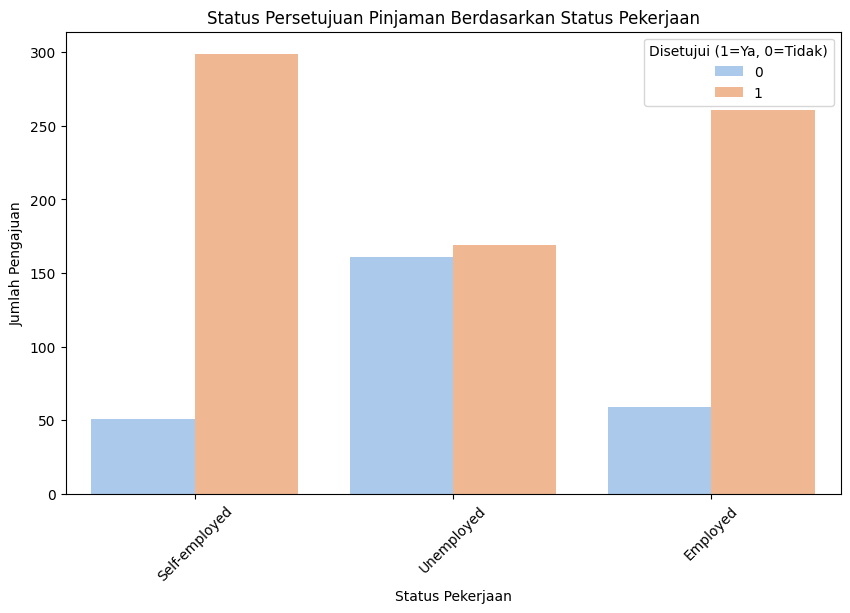

In [ ]:
status_counts = df['employment_status'].value_counts().head(3)
filter = df[df['employment_status'].isin(status_counts.index)]

plt.figure(figsize=(10, 6))
sns.countplot(x='employment_status', data=filter, hue="loan_approved", palette='pastel', order=status_counts.index)
plt.title('Status Persetujuan Pinjaman Berdasarkan Status Pekerjaan')
plt.xlabel('Status Pekerjaan')
plt.ylabel('Jumlah Pengajuan')
plt.legend(title='Disetujui (1=Ya, 0=Tidak)')
plt.xticks(rotation=45)
plt.show()

##**Pie Chart Proporsi Beban Pinjaman**

Berdasarkan hasil visualisasi Pie Chart, kelompok Beban Tinggi (39.7%) dan Beban Sedang (34.1%) menguasai portofolio dengan total gabungan mencapai 73.8%. Hal ini menunjukkan bahwa **mayoritas pemohon pinjaman memiliki rasio utang yang cukup besar** terhadap pendapatan mereka. Sebaliknya, kelompok Beban Ringan hanya mencakup 26.2%, yang berarti ketersediaan peminjam dengan profil finansial dalam batas amman masih menjadi minoritas.

Yang harus dilakukan yaitu perusahaan perlu **memperketat standar rasio utang terhadap pendapatan** bagi kategori Beban Tinggi serta memberikan **insentif suku bunga rendah khusus** untuk menarik nasabah kategori Beban Ringan. Selain itu, **menawarkan program tenor** bagi kelompok Beban Sedang guna mencegah risiko gagal bayar di masa depan.

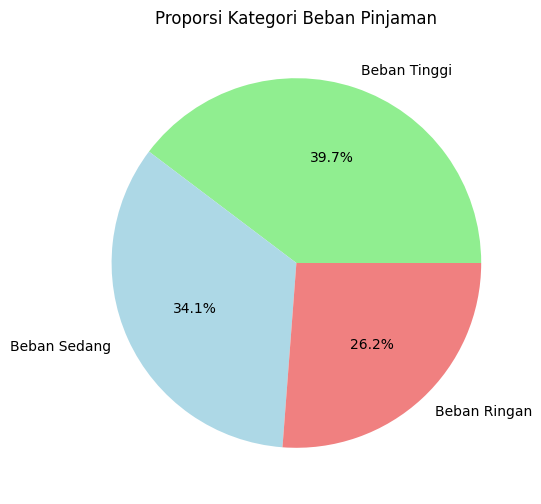

In [ ]:
plt.figure(figsize=(10, 6))
plt.pie(df['income_loan_category'].value_counts(),
        labels=df['income_loan_category'].value_counts().index,
        autopct='%1.1f%%',
        colors=['lightgreen', 'lightblue', 'lightcoral'])
plt.title('Proporsi Kategori Beban Pinjaman')
plt.show()

##**Line Chart Tren Persetujuan Berdasarkan Usia**

Berdasarkan hasil visualisasi Line Chart, tingkat persetujuan pinjaman menunjukkan **perubahan yang naik turun di berbagai kelompok usia** tanpa tren linear yang jelas. Rasio persetujuan tertinggi (puncak) terlihat pada usia sekitar 27 tahun dan 32 tahun yang mencapai angka di atas 0.90, menandakan **kelompok usia produktif awal memiliki tingkat penerimaan yang sangat baik**. Sebaliknya, terdapat penurunan drastis pada beberapa titik usia spesifik seperti usia 24, 26, 39, 57, dan 63 tahun, yang menunjukkan adanya anomali atau kriteria risiko yang lebih ketat pada usia-usia tersebut.

Yang harus dilakukan oleh perusahaan yaitu melakukan **audit terhadap parameter penilaian kredit** pada usia-usia dengan tingkat persetujuan rendah guna memastikan tidak ada bias sistem atau kesalahan data. Selain itu, perusahaan dapat **merancang produk pinjaman yang fleksibel** bagi kelompok usia yang mengalami fluktuasi tajam serta melakukan **analisis korelasi antara usia dengan variabel pendapatan** untuk memahami penyebab ketidakstabilan rasio persetujuan tersebut.


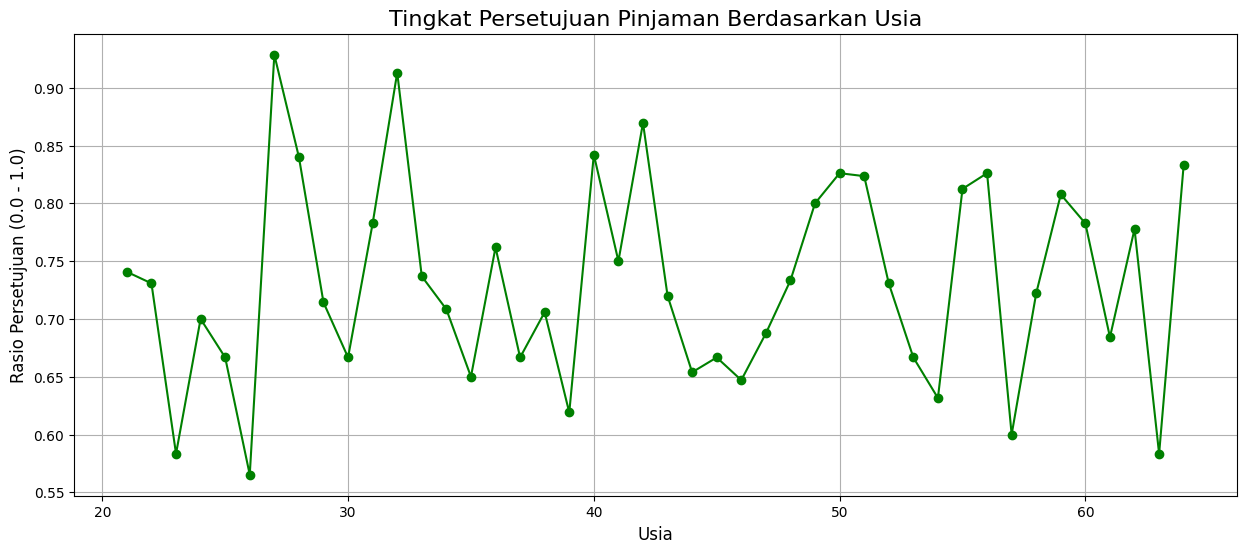

In [ ]:
age_trend = df.groupby('age')['loan_approved'].mean()

plt.figure(figsize=(15, 6))
plt.plot(age_trend.index, age_trend.values, marker='o', color='green')

plt.title('Tingkat Persetujuan Pinjaman Berdasarkan Usia', fontsize=16)
plt.xlabel('Usia', fontsize=12)
plt.ylabel('Rasio Persetujuan (0.0 - 1.0)', fontsize=12)
plt.grid(True)
plt.show()

##**Histogram Distribusi Skor Kredit**

Berdasarkan visualisasi histogram, distribusi skor kredit pemohon menunjukkan **pola yang relatif merata** di seluruh rentang skor dari 300 hingga 850. Tidak terlihat adanya penumpukan yang signifikan pada skor tinggi maupun rendah, meskipun puncak frekuensi tertinggi ada pada skor sekitar 470–500 dan 650–680. Hal ini berarti **basis pemohon pinjaman berasal dari berbagai profil risiko kredit**, mulai dari yang berisiko tinggi hingga yang aman atau berisiko rendah.

Perusahaan perlu **menerapkan strategi segmentasi penawaran** dengan menetapkan suku bunga berjenjang berdasarkan skor kredit untuk mengoptimalkan keuntungan dari kelompok skor tinggi dan mengurangi risiko dari kelompok skor rendah. Selain itu, karena banyaknya pemohon dengan skor kredit menengah ke bawah, perusahaan dapat menyediakan **program edukasi keuangan atau perbaikan kredit** untuk membantu nasabah meningkatkan skor mereka sehingga layak mendapatkan pinjaman di masa mendatang.



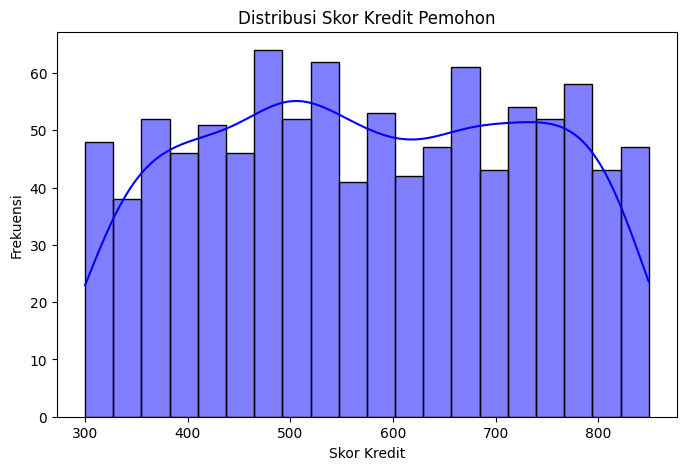

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['credit_score'], bins=20, kde=True, color='blue')
plt.title('Distribusi Skor Kredit Pemohon')
plt.xlabel('Skor Kredit')
plt.ylabel('Frekuensi')
plt.show()

##**BoxPlot Sebaran Pinjaman Berdasarkan Status Pernikahan**

Berdasarkan hasil visualisasi Boxplot, sebaran jumlah pinjaman di antara ketiga kelompok **status pernikahan (Married, Single, Divorced) menunjukkan profil yang serupa** dengan nilai median berada di kisaran 25.000 hingga 28.000. Kelompok Single memiliki nilai median yang sedikit lebih tinggi dibandingkan kelompok lainnya, namun secara keseluruhan, rentang pinjaman dan nilai maksimum (mendekati 50.000) terlihat sama. Hal ini berarti **status pernikahan bukan merupakan faktor pembeda utama** yang membatasi nominal jumlah pinjaman yang diajukan atau disetujui.

Yang harus dilakukan yaitu perusahaan sebaiknya **menerapkan kebijakan batas pinjaman yang setara** bagi semua status pernikahan karena tidak adanya perbedaan kebutuhan dana yang signifikan secara statistik. Selain itu, karena profil pinjaman kelompok Single sedikit lebih tinggi, perusahaan dapat **menawarkan fitur asuransi jiwa** atau perlindungan tambahan untuk memitigasi risiko karena kelompok single umumnya tidak memiliki dukungan finansial dari atau secondary income jika terjadi gagal bayar.

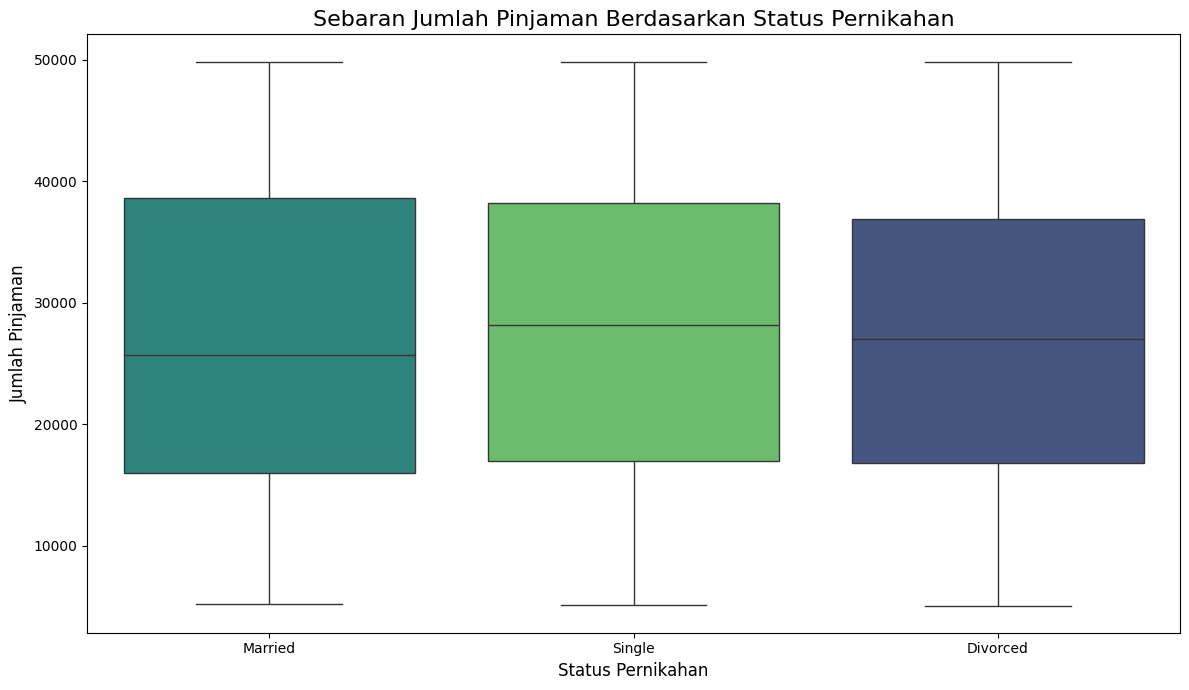

In [ ]:
marital_order = df['marital_status'].value_counts().index

plt.figure(figsize=(12, 7))
sns.boxplot(x='marital_status', y='loan_amount', data=df, palette='viridis', order=marital_order, hue='marital_status', legend=False)
plt.title('Sebaran Jumlah Pinjaman Berdasarkan Status Pernikahan', fontsize=16)
plt.xlabel('Status Pernikahan', fontsize=12)
plt.ylabel('Jumlah Pinjaman', fontsize=12)
plt.tight_layout()
plt.show()

##**Scatter Plot Perbandingan Pendapatan dan Jumlah Pinjaman**

Berdasarkan hasil visualisasi scatter plot, terlihat bahwa titik-titik data tersebar secara acak di seluruh area grafik tanpa membentuk pola garis tertentu, yang menunjukkan **tidak adanya korelasi linear yang kuat antara pendapatan tahunan dan jumlah pinjaman** yang diajukan. Nasabah dengan pendapatan rendah tetap ada yang mengajukan pinjaman dalam jumlah besar, begitu pula sebaliknya. Selain itu, sebaran titik persetujuan (oranye) dan penolakan (biru) tersebar merata di berbagai level pendapatan, berarti **pendapatan bukan satu-satunya faktor penentu utama dalam status persetujuan pinjaman.**

Yang harus dilakukan perusahaan sebaiknya beralih dari penilaian berbasis pendapatan tunggal ke **analisis kapasitas pembayaran** yang lebih menyeluruh dengan mempertimbangkan variabel lain seperti pengeluaran bulanan atau riwayat kredit. Selain itu, perlu dilakukan **segmentasi penawaran jumlah pinjaman** yang lebih seimbang terhadap pendapatan guna mencegah utang berlebih pada nasabah berpendapatan rendah demi menjaga portofolio kredit.

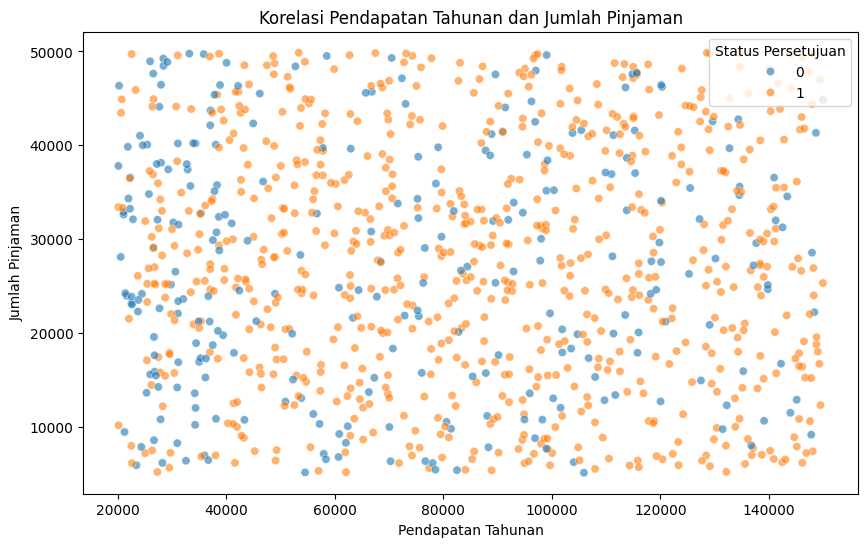

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='annual_income', y='loan_amount', hue='loan_approved', data=df, alpha=0.6)
plt.title('Korelasi Pendapatan Tahunan dan Jumlah Pinjaman')
plt.xlabel('Pendapatan Tahunan')
plt.ylabel('Jumlah Pinjaman')
plt.legend(title='Status Persetujuan')
plt.show()

##**Bubble Chart Analisis Pendapatan, Pinjaman, dan Skor Kredit**

Visualisasi ini dengan jelas membagi profil risiko nasabah menjadi tiga wilayah berdasarkan rasio pinjaman terhadap pendapatan:

* Beban Tinggi (Oranye): Berfokus pada nasabah dengan pendapatan
rendah namun memiliki jumlah pinjaman besar (kiri atas), yang merupakan zona risiko kritis.

* Beban Sedang (Merah Muda): Berada di area diagonal tengah, menunjukkan keseimbangan proporsional antara pendapatan dan pinjaman.

* Beban Ringan (Ungu): Terletak pada nasabah berpendapatan tinggi dengan jumlah pinjaman yang relatif kecil (kanan bawah).

* Variasi Skor Kredit: Ukuran bubble menunjukkan skor kredit tersebar secara acak di semua kategori beban. Hal ini mengindikasikan bahwa nasabah dengan Beban Tinggi tetap bisa memiliki skor kredit tinggi, yang mungkin dapat mengurangi risiko gagal bayar yang sebenarnya jika hanya melihat skor kredit tanpa melihat rasio beban.

Yang harus dilakukan perusahaan yaitu **menerapkan kebijakan pinjaman dinamis** yang disesuaikan dengan level pendapatan untuk mencegah nasabah baru masuk ke zona "Beban Tinggi" (kiri atas). Selain itu, nasabah yang sudah berada di kategori Beban Tinggi dengan skor kredit rendah (bubble kecil), perusahaan perlu **melakukan peninjauan ulang fasilitas kredit** (limit reduction) untuk mengurangi kerugian. Sebaliknya, nasabah di kategori Beban Ringan dengan skor kredit tinggi harus dijadikan target utama untuk **program top-up pinjaman** karena kapasitas bayar mereka yang sangat longgar.

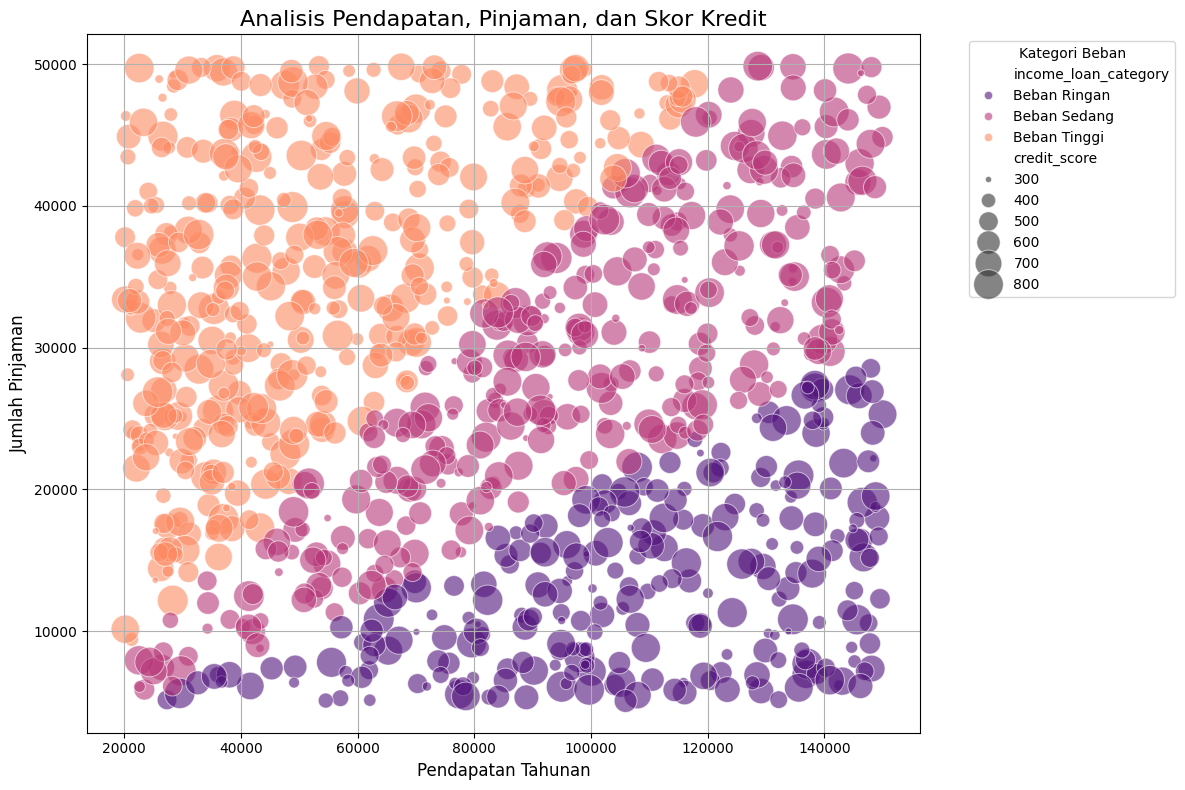

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='annual_income', y='loan_amount', size='credit_score', hue='income_loan_category',
                data=df, sizes=(20, 500), alpha=0.6, palette='magma')
plt.title('Analisis Pendapatan, Pinjaman, dan Skor Kredit', fontsize=16)
plt.xlabel('Pendapatan Tahunan', fontsize=12)
plt.ylabel('Jumlah Pinjaman', fontsize=12)
plt.grid(True)
plt.legend(title='Kategori Beban', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##**Heatmap Korelasi Faktor Penentu Kelayakan Pinjaman**

Berdasarkan matriks korelasi, **skor kredit (credit score) merupakan faktor yang memiliki hubungan paling kuat terhadap persetujuan pinjaman (0.35)**, diikuti oleh pendapatan tahunan (annual income) dengan nilai 0.18. Sebaliknya, jumlah pinjaman (loan amount) hampir tidak memiliki pengaruh langsung terhadap status persetujuan (0.02). Selain itu, **tidak ditemukan korelasi yang signifikan antar variabel independen** (seperti pendapatan terhadap skor kredit yang hanya 0.02), yang mengindikasikan bahwa setiap faktor berdiri sendiri dalam menentukan kelayakan nasabah.

Yang harus dilakukan perusahaan yaitu **menjadikan skor kredit sebagai bobot utama dalam sistem penilaian** karena terbukti menjadi prediktor paling akurat bagi kelayakan pinjaman. Selain itu, perusahaan dapat **mengabaikan nominal jumlah pinjaman** sebagai faktor penghambat persetujuan selama skor kredit dan pendapatan pengaju masih memenuhi standar, serta mulai **mengembangkan model penilaian risiko** karena korelasi variabel yang ada saat ini masih tergolong lemah.

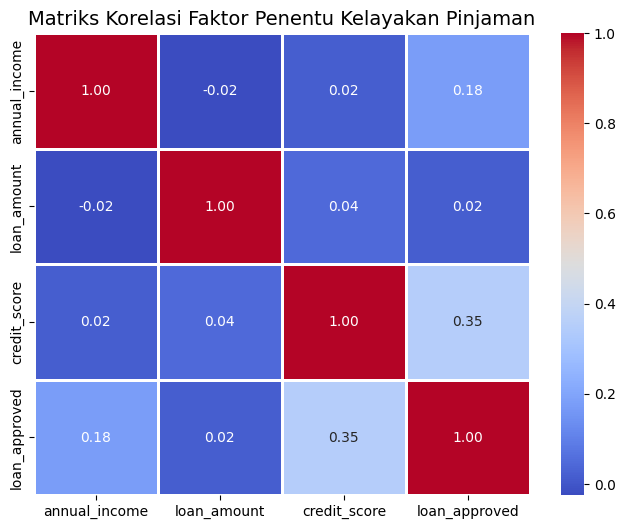

In [ ]:
plt.figure(figsize=(8, 6))
cols_relevan = ['annual_income', 'loan_amount', 'credit_score', 'loan_approved']

sns.heatmap(data=df[cols_relevan].corr(),annot=True,cmap='coolwarm',fmt='.2f',linewidths=0.8)

plt.title('Matriks Korelasi Faktor Penentu Kelayakan Pinjaman',fontsize=14)
plt.show()

#**Menyimpan Dataset**

In [ ]:
df.to_csv('/content/drive/MyDrive/loan_data/loanapproval.csv', index=False)